# Bifurcation Analysis

Marius Pille (Berlin Institute of Health at Charité University
Medicine)  
Leon Martin (Berlin Institute of Health at Charité University
Medicine)  
Leon Stefanovski (Charité University Medicine Berlin)

## Goals

-   Build intuition for **fixed points, stability, and bifurcations**
    from scalar and 2D normal forms.
-   Run a **numerical continuation** in TVBO with one YAML and a single
    `exp.run(backend)` call.
-   Read a brain-relevant bifurcation diagram (Generic2dOscillator) and
    connect it to network-level regimes.

Bifurcation analysis tells us *how the qualitative behaviour of a model
changes when we move a parameter*. In TVBO every example below is just
**inline YAML + plotting** — no Fortran files, no scratch directories.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tvbo import Dynamics, Continuation, SimulationExperiment
from tvbo.datamodel.schema import Exploration, ExplorationAxis

## 1. Linear stability — sign of $a$ decides everything

The simplest dynamical system is

$$
\dot x = a\,x, \qquad x(0) = x_0, \qquad x(t) = x_0\,e^{a t}.
$$

For $a < 0$ the origin is a **stable** fixed point, for $a > 0$ it is
**unstable**, and $a = 0$ is the prototype of a **bifurcation**.


STEP 1: Running simulation...
  Simulation period: 4.0 ms, dt: 0.001 ms
  Transient period: 0.0 ms
  Simulation complete.

STEP 2: Running explorations...
  > a_sweep
  Explorations complete.

Experiment complete.

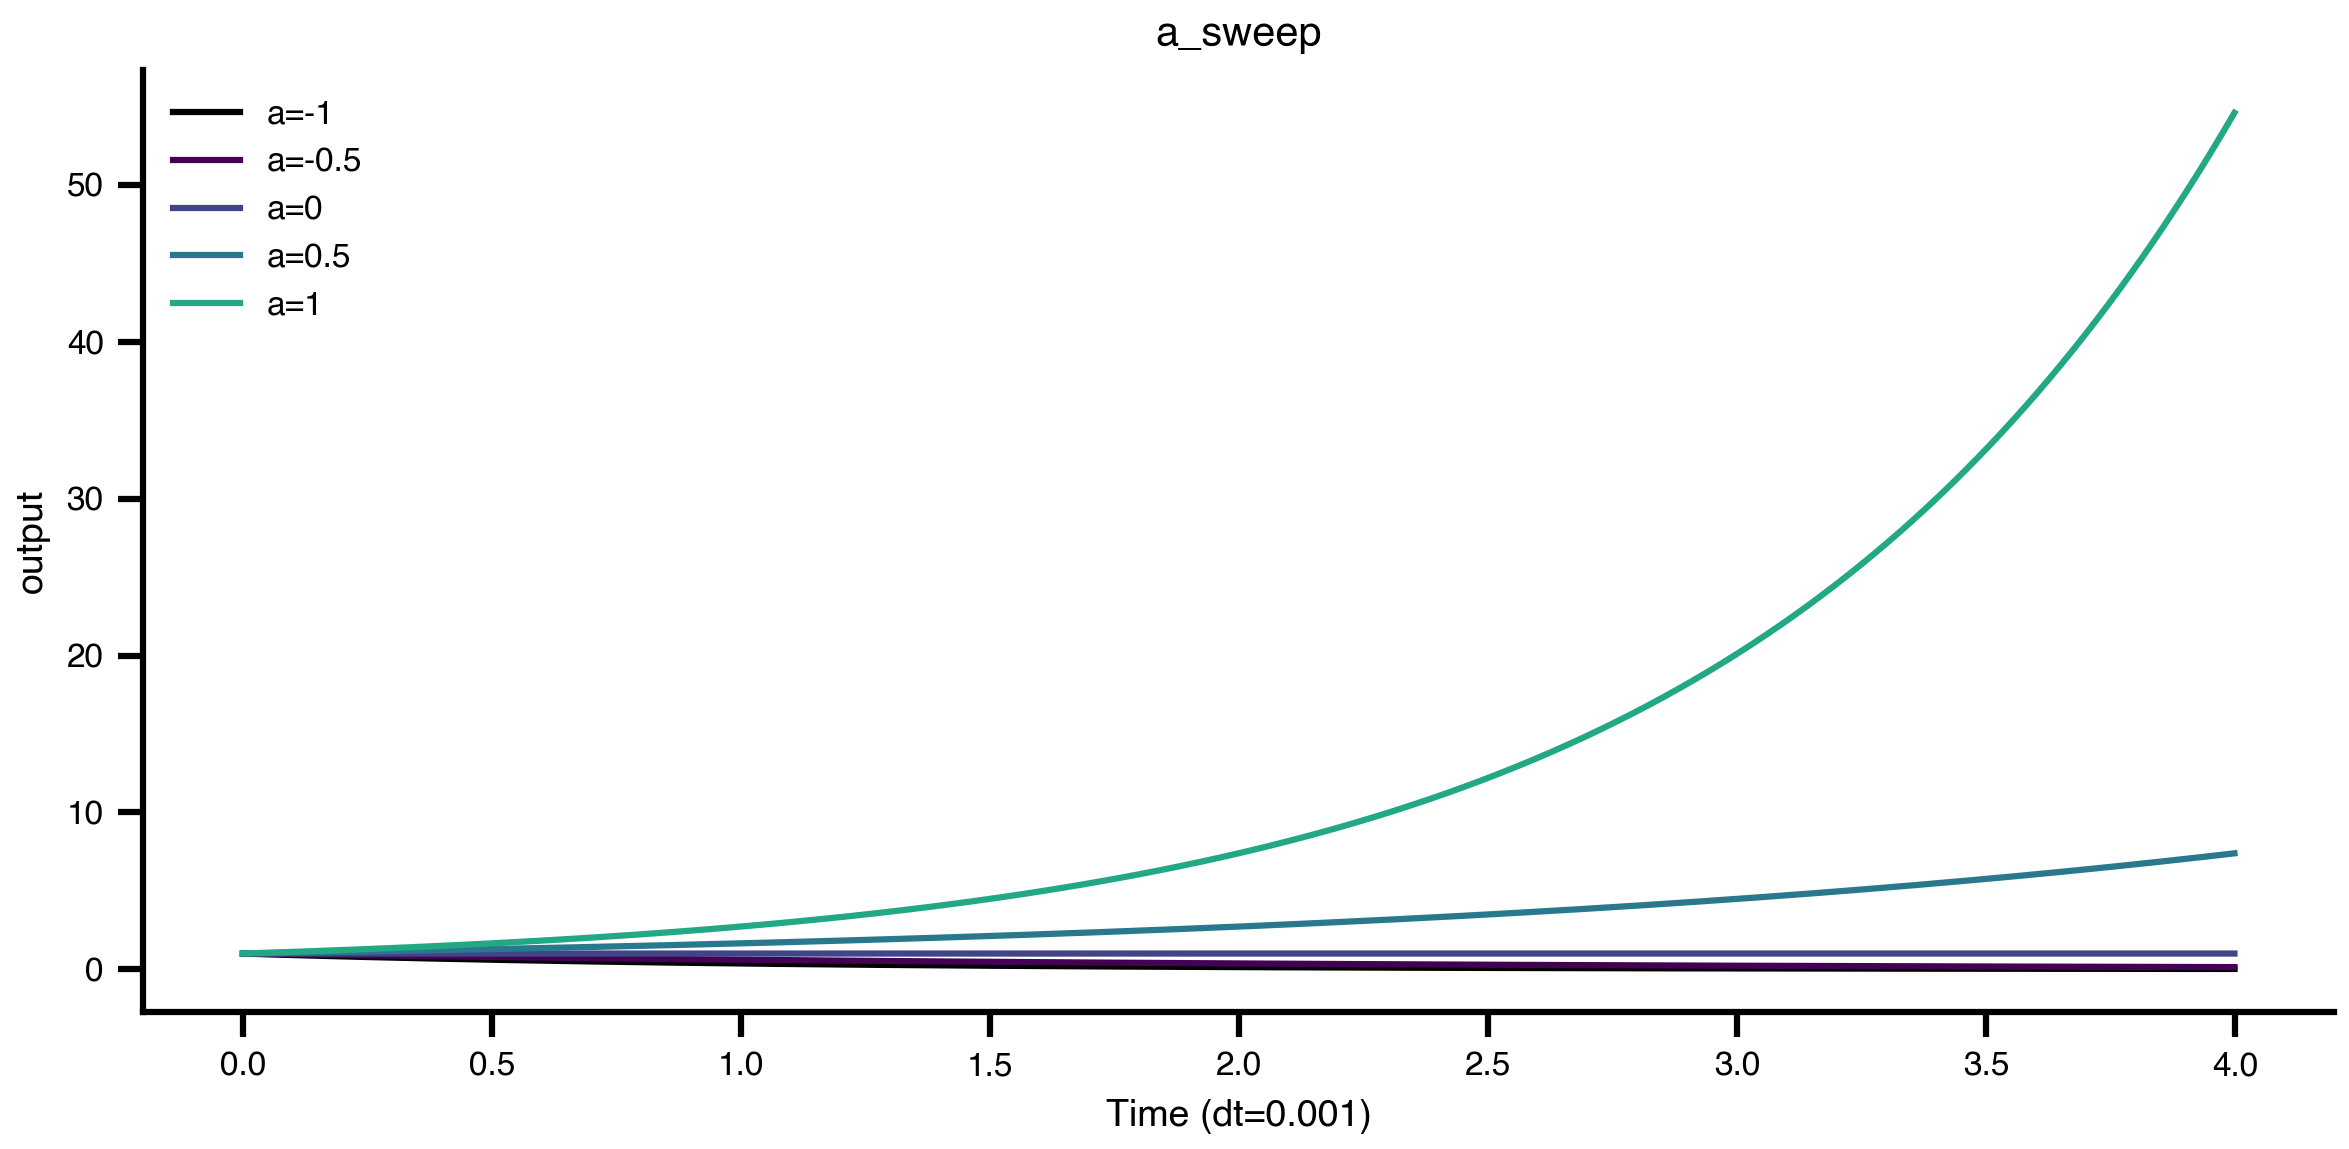

In [2]:
LIN = """
name: LinearScalar
parameters:
  a:
    name: a
    value: 1.0
state_variables:
  x:
    name: x
    equation:
      lhs: Derivative(x, t)
      rhs: a*x
    initial_value: 1.0
"""

exp_lin = SimulationExperiment(dynamics=Dynamics.from_string(LIN))
exp_lin.integration.duration = 4
exp_lin.integration.step_size = 1e-3
exp_lin.explorations["a_sweep"] = Exploration(
    name="a_sweep",
    space=ExplorationAxis(parameter="a", explored_values=[-1.0, -0.5, 0.0, 0.5, 1.0]),
)
exp_lin.run("tvboptim").explorations["a_sweep"].plot(overlay=True)

The slope at $t = 0$ equals $a$ — its sign decides growth vs. decay. For
nonlinear systems $\dot x = f(x)$, stability of an equilibrium $x^*$ is
governed by the **Jacobian eigenvalues**
$J = \partial f/\partial x|_{x^*}$. Everything that follows is built
from this idea.

## 2. 2D phase portraits — node, saddle, focus, centre

For $\dot{\vec x} = A\vec x$ in 2D, the eigenvalues of $A$ classify the
origin. TVBO’s `kind="phaseplane"` overlays the vector field with both
nullclines and the detected fixed points.

Each system below is a complete, copy-pastable YAML. We feed it directly
to `Dynamics.from_string` — no helper functions, no string
interpolation.

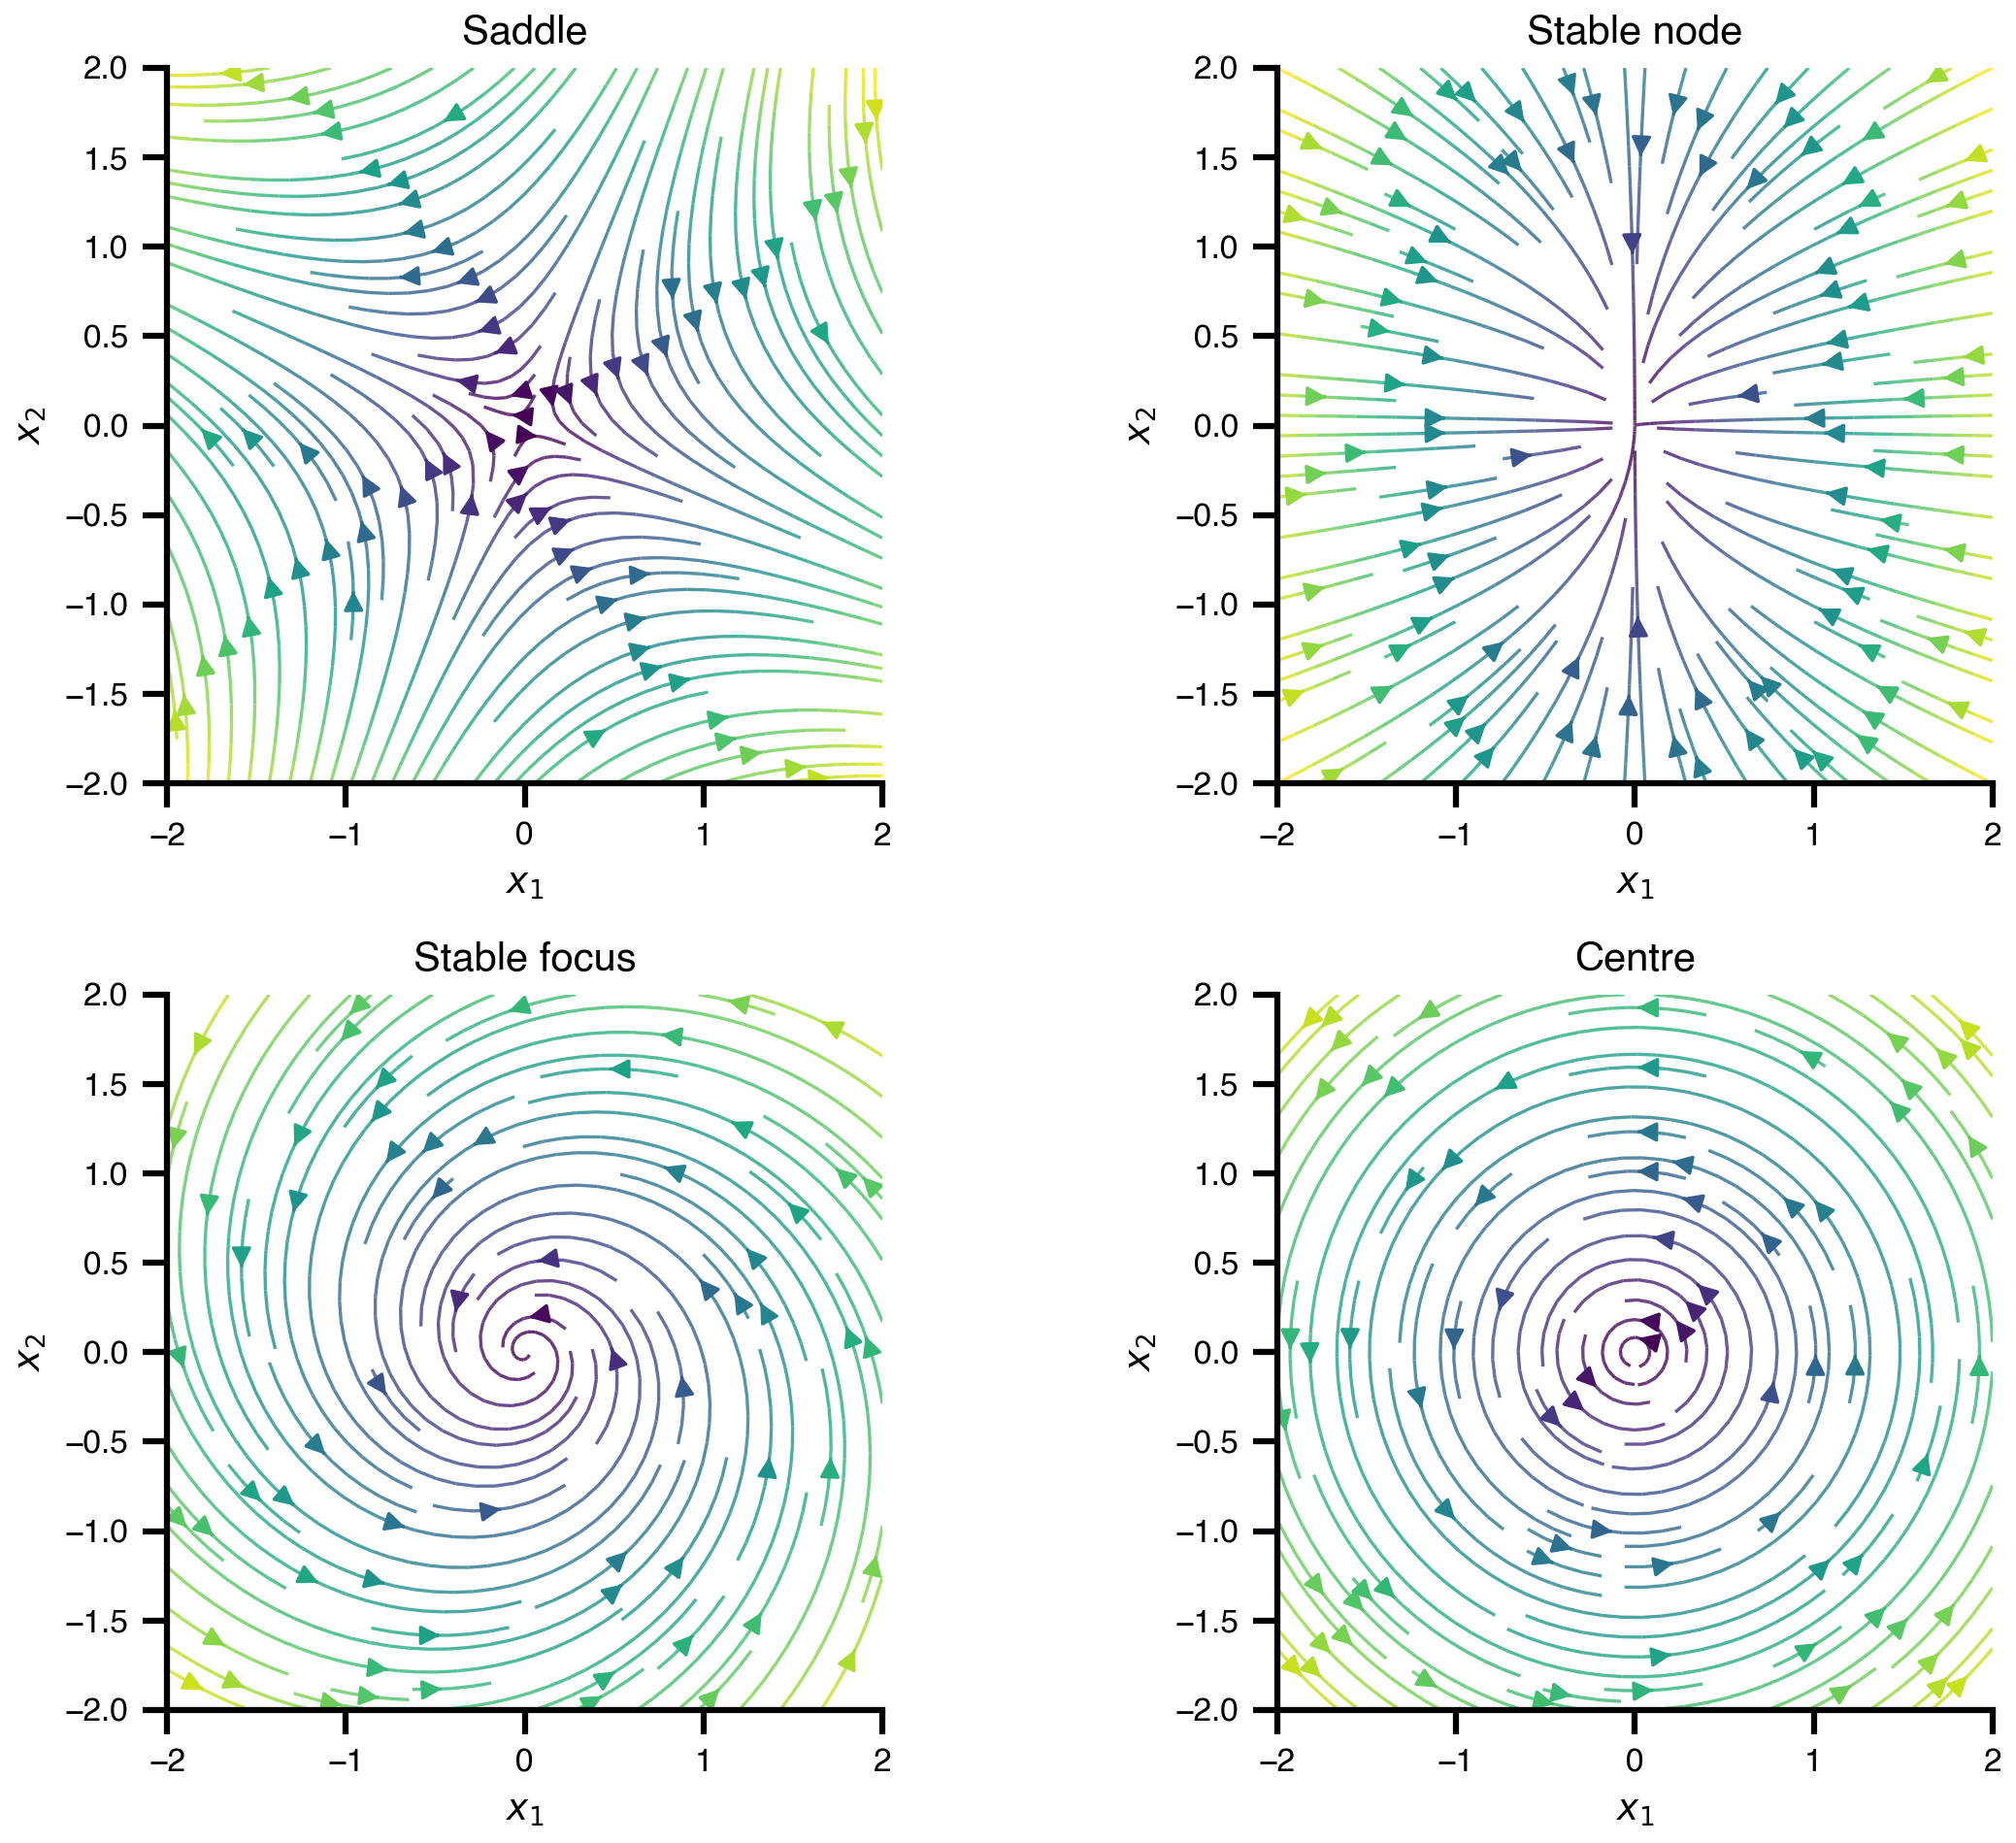

In [3]:
SADDLE = """
name: Saddle
state_variables:
  x1:
    name: x1
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x1, t)
      rhs: x1 - x2
    initial_value: 1.0
  x2:
    name: x2
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x2, t)
      rhs: -x1 - x2
    initial_value: 1.0
"""

STABLE_NODE = """
name: StableNode
state_variables:
  x1:
    name: x1
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x1, t)
      rhs: -2*x1
    initial_value: 1.0
  x2:
    name: x2
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x2, t)
      rhs: -x2
    initial_value: 1.0
"""

STABLE_FOCUS = """
name: StableFocus
state_variables:
  x1:
    name: x1
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x1, t)
      rhs: -0.3*x1 - x2
    initial_value: 1.0
  x2:
    name: x2
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x2, t)
      rhs: x1 - 0.3*x2
    initial_value: 1.0
"""

CENTRE = """
name: Centre
state_variables:
  x1:
    name: x1
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x1, t)
      rhs: -x2
    initial_value: 1.0
  x2:
    name: x2
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x2, t)
      rhs: x1
    initial_value: 1.0
"""

CASES = [
    ("Saddle",       SADDLE),
    ("Stable node",  STABLE_NODE),
    ("Stable focus", STABLE_FOCUS),
    ("Centre",       CENTRE),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 6.5))
for ax, (label, yml) in zip(axes.flat, CASES):
    dyn = Dynamics.from_string(yml)
    dyn.plot("x1", "x2", kind="vectorfield", ax=ax,
             grid_n=20, n_trajectories=3, duration=15)
    ax.set_title(label, fontsize=10)
plt.tight_layout(); plt.show()

Bifurcations occur when an eigenvalue of $A$ — or, locally, of the
Jacobian — **crosses the imaginary axis** as a parameter is varied.

## 3. The three codim-1 normal forms

We cover the canonical scalar bifurcations and let TVBO continue the
equilibrium branch *bidirectionally*. Each example is a self-contained
YAML pair (`Dynamics` + `Continuation`) passed straight into
`from_string`.

### Saddle-node — $\dot x = a - x^2$

Two equilibria collide and annihilate at $a = 0$. Beyond the fold *no
attractor* survives. This is the prototype for **regime shifts**.

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
CT: 1.015661 seconds (3.34 M allocations: 167.280 MiB, 2.86% gc time, 99.81% compilation time)
CT: 0.000388 seconds (7.60 k allocations: 318.734 KiB)

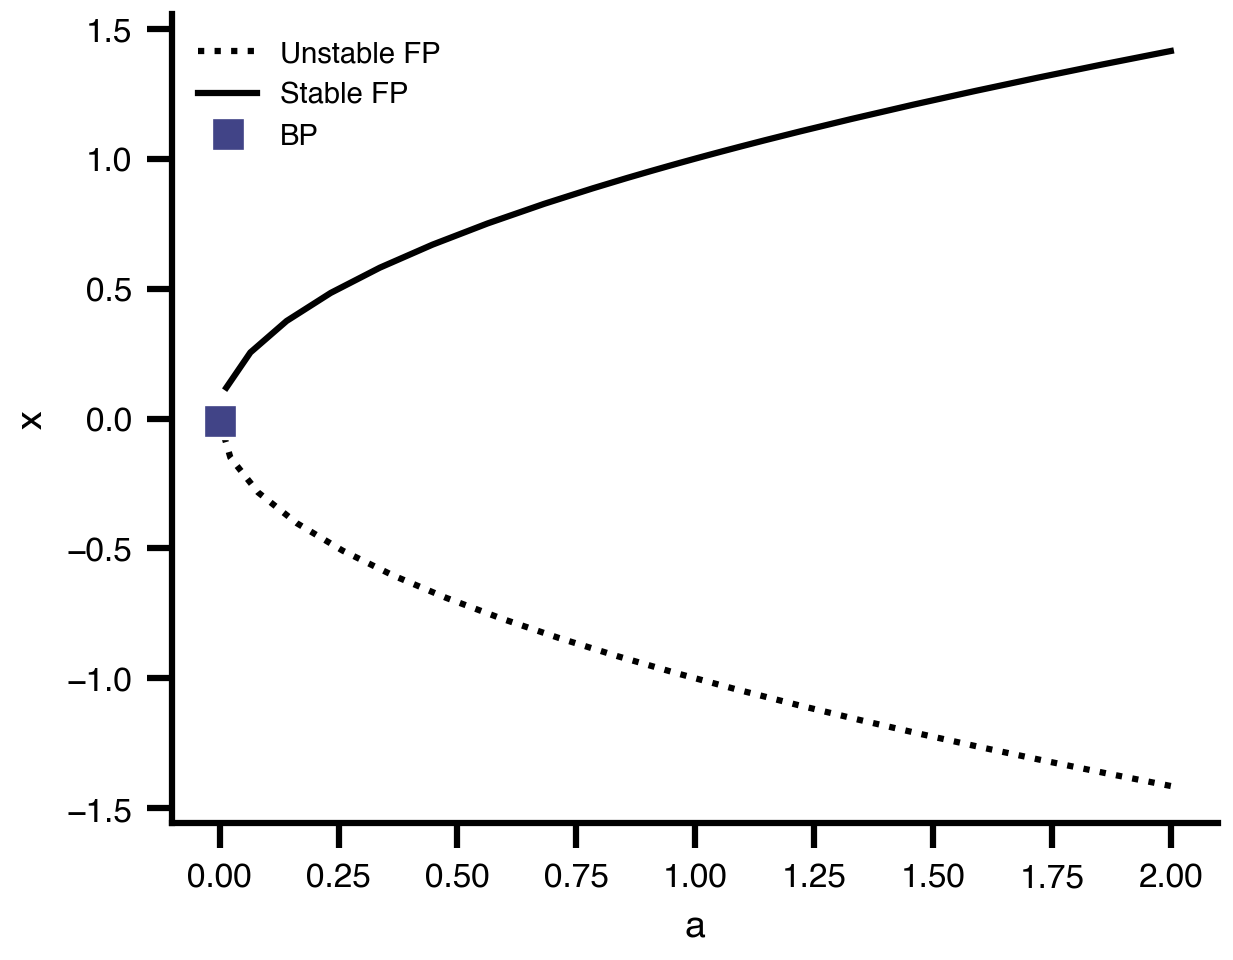

In [4]:
SADDLE_NODE = """
name: SaddleNode
parameters:
  a:
    name: a
    value: 1.0
state_variables:
  x:
    name: x
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x, t)
      rhs: a - x**2
    initial_value: 1.0
"""

SADDLE_NODE_CONT = """
name: saddle_node_cont
dynamics: SaddleNode
free_parameters:
  - name: a
    domain:
      lo: -2.0
      hi: 2.0
max_steps: 400
ds: 0.01
bothside: true
"""

exp_sn = SimulationExperiment(
    dynamics=Dynamics.from_string(SADDLE_NODE),
    continuations=[Continuation.from_string(SADDLE_NODE_CONT)],
)
exp_sn.run("bifurcationkit.jl").continuations["saddle_node_cont"].plot(VOI="x")
plt.show()


STEP 1: Running simulation...
  Simulation period: 1000.0 ms, dt: 0.01220703125 ms
  Transient period: 0.0 ms
  Simulation complete.

Experiment complete.

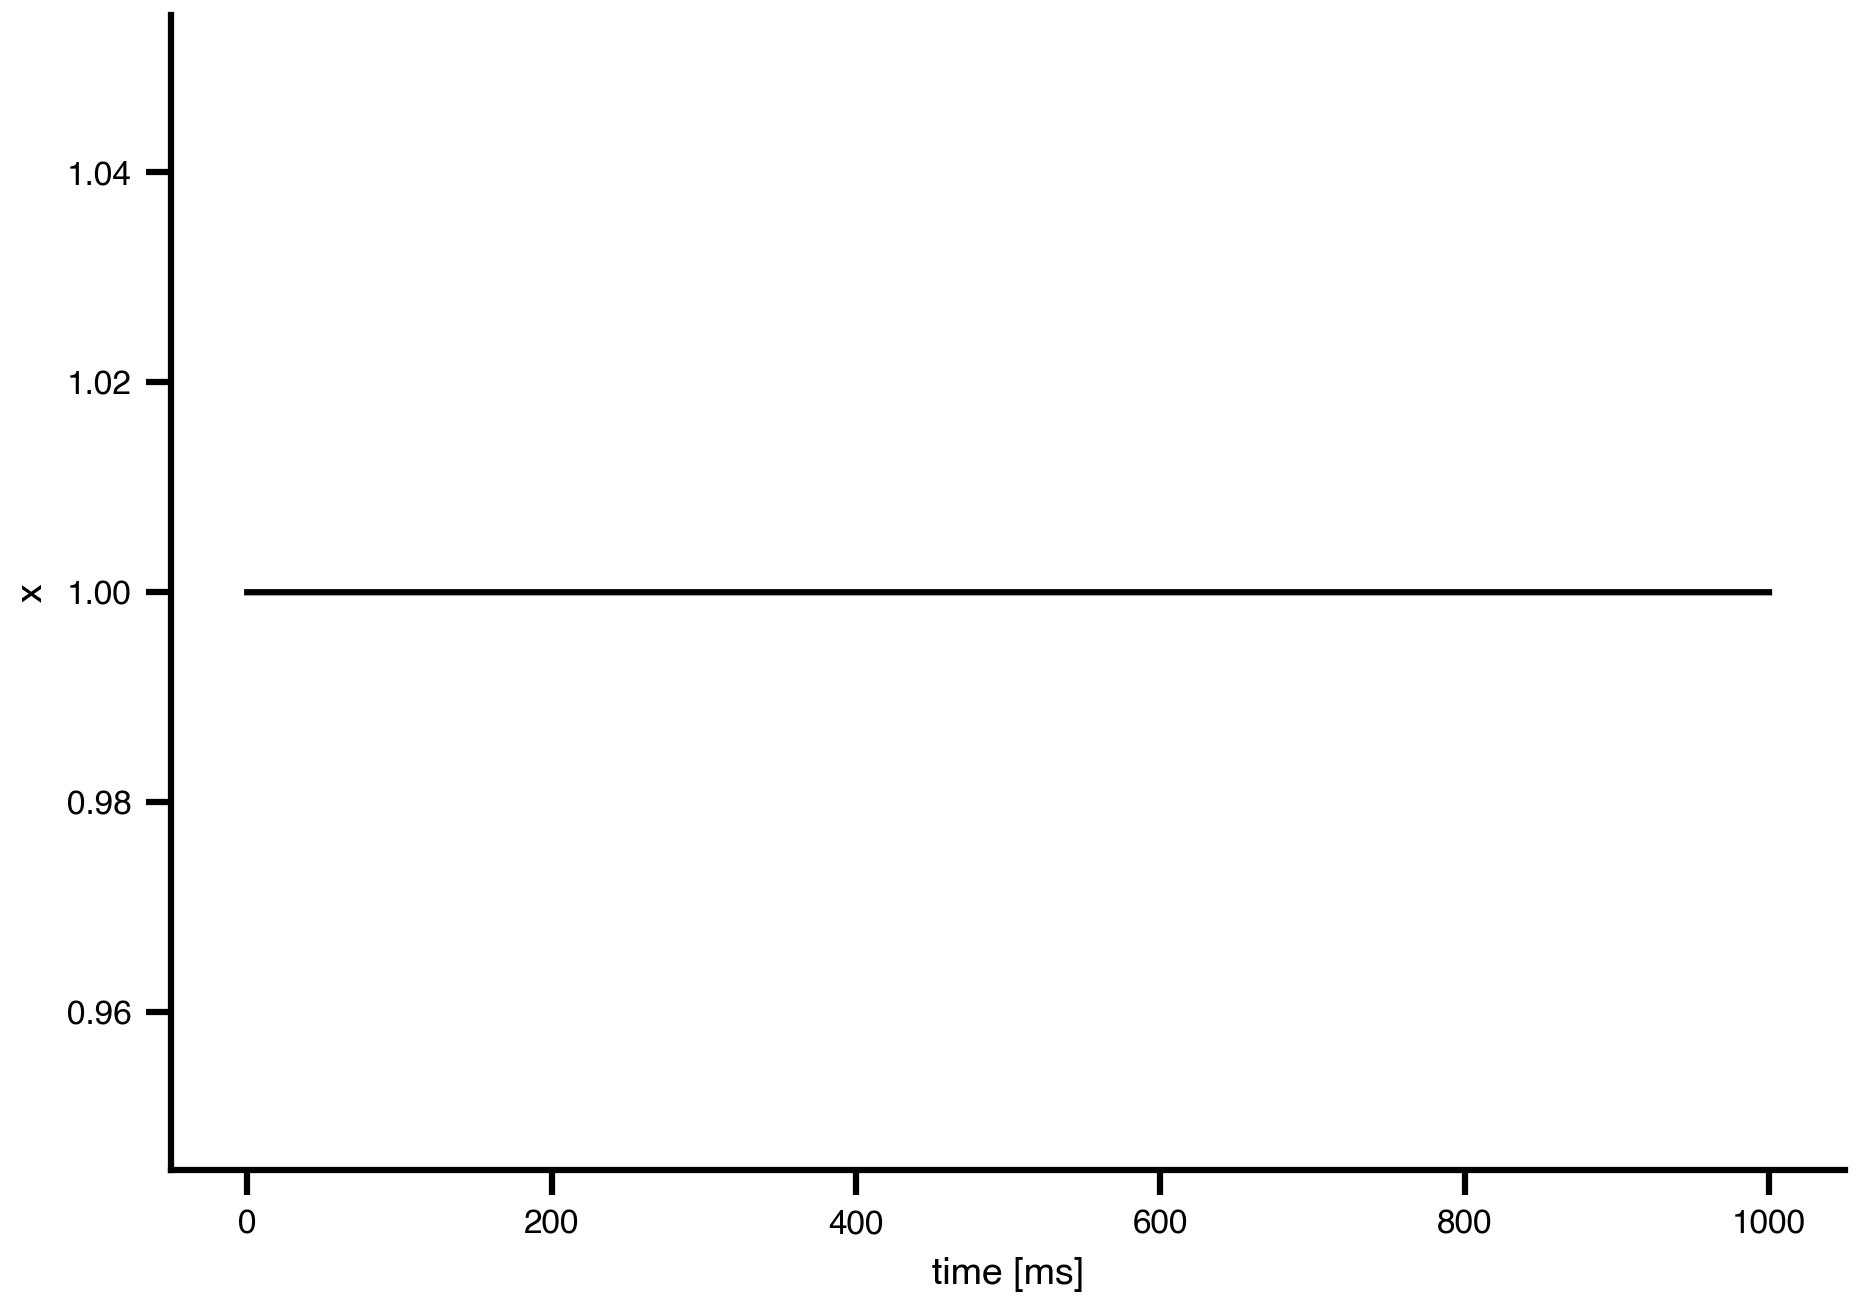

In [5]:
exp_sn.run('tvboptim').plot()

### Hysteresis — $\dot x = a + x - x^3$

A small constant tilt unfolds the pitchfork into **two** saddle-nodes
framing a bistable region. Sweeping $a$ up then down traces a memory
loop.

CT: 0.409750 seconds (806.00 k allocations: 39.254 MiB, 99.91% compilation time)
CT: 0.000528 seconds (10.88 k allocations: 451.875 KiB)

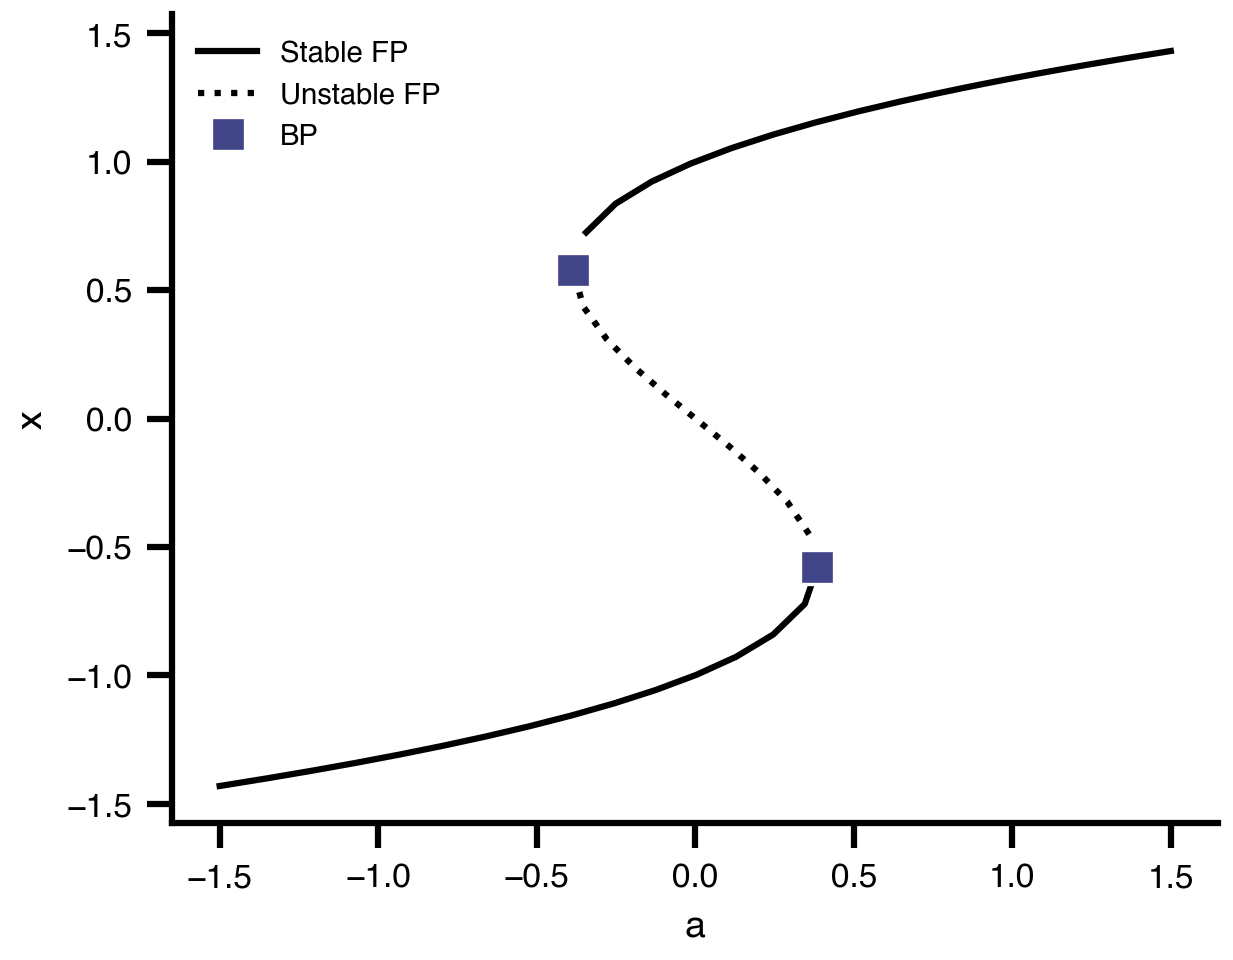

In [6]:
HYSTERESIS = """
name: Hysteresis
parameters:
  a:
    name: a
    value: 1.0
state_variables:
  x:
    name: x
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x, t)
      rhs: a + x - x**3
    initial_value: 1.0
"""

HYSTERESIS_CONT = """
name: hysteresis_cont
dynamics: Hysteresis
free_parameters:
  - name: a
    domain:
      lo: -1.5
      hi: 1.5
max_steps: 400
ds: 0.01
bothside: true
"""

exp_hy = SimulationExperiment(
    dynamics=Dynamics.from_string(HYSTERESIS),
    continuations=[Continuation.from_string(HYSTERESIS_CONT)],
)
exp_hy.run("bifurcationkit.jl").continuations["hysteresis_cont"].plot(VOI="x")
plt.show()

Two `Exploration`s over $a$ — one starting from $x_0 = -1$, one from
$x_0 = +1$ — expose the bistable region: for the same $a$, each initial
condition lands on a different attractor.


STEP 1: Running simulation...
  Simulation period: 200.0 ms, dt: 0.01 ms
  Transient period: 0.0 ms
  Simulation complete.

STEP 2: Running explorations...
  > a
  Explorations complete.

Experiment complete.

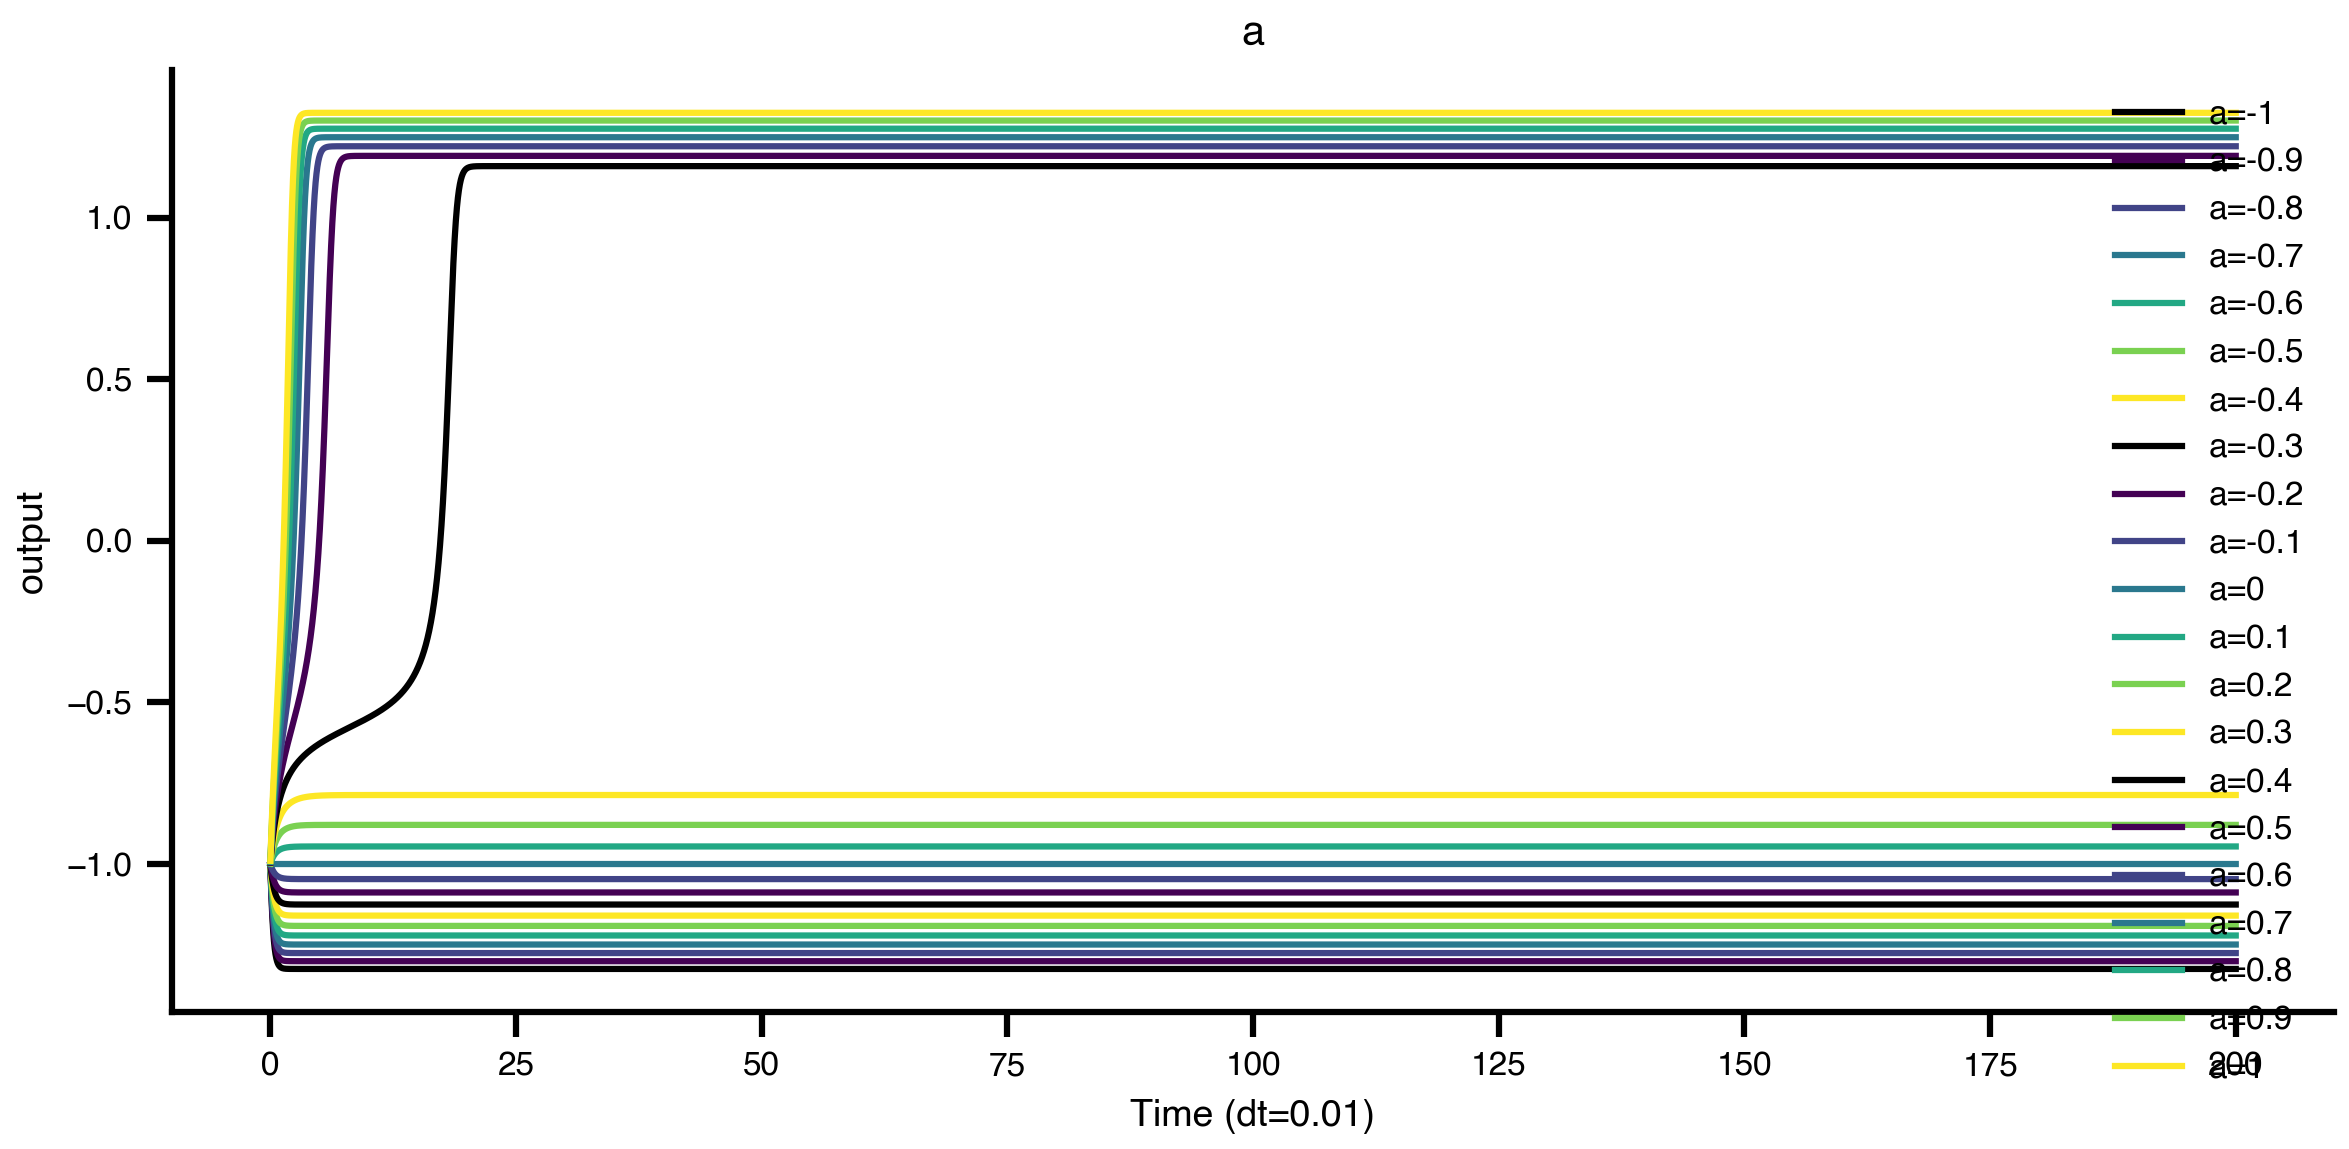

In [7]:
dyn_lo = Dynamics.from_string(HYSTERESIS)
dyn_lo.state_variables["x"].initial_value = -1.0
exp_hy_lo = SimulationExperiment(dynamics=dyn_lo)
exp_hy_lo.integration.duration = 200
exp_hy_lo.integration.step_size = 0.01
exp_hy_lo.explorations["a"] = Exploration(
    name="a",
    space=ExplorationAxis(parameter="a", explored_values=list(np.linspace(-1.0, 1.0, 21))),
)
exp_hy_lo.run("tvboptim").explorations["a"].plot(overlay=True)


STEP 1: Running simulation...
  Simulation period: 200.0 ms, dt: 0.01 ms
  Transient period: 0.0 ms
  Simulation complete.

STEP 2: Running explorations...
  > a
  Explorations complete.

Experiment complete.

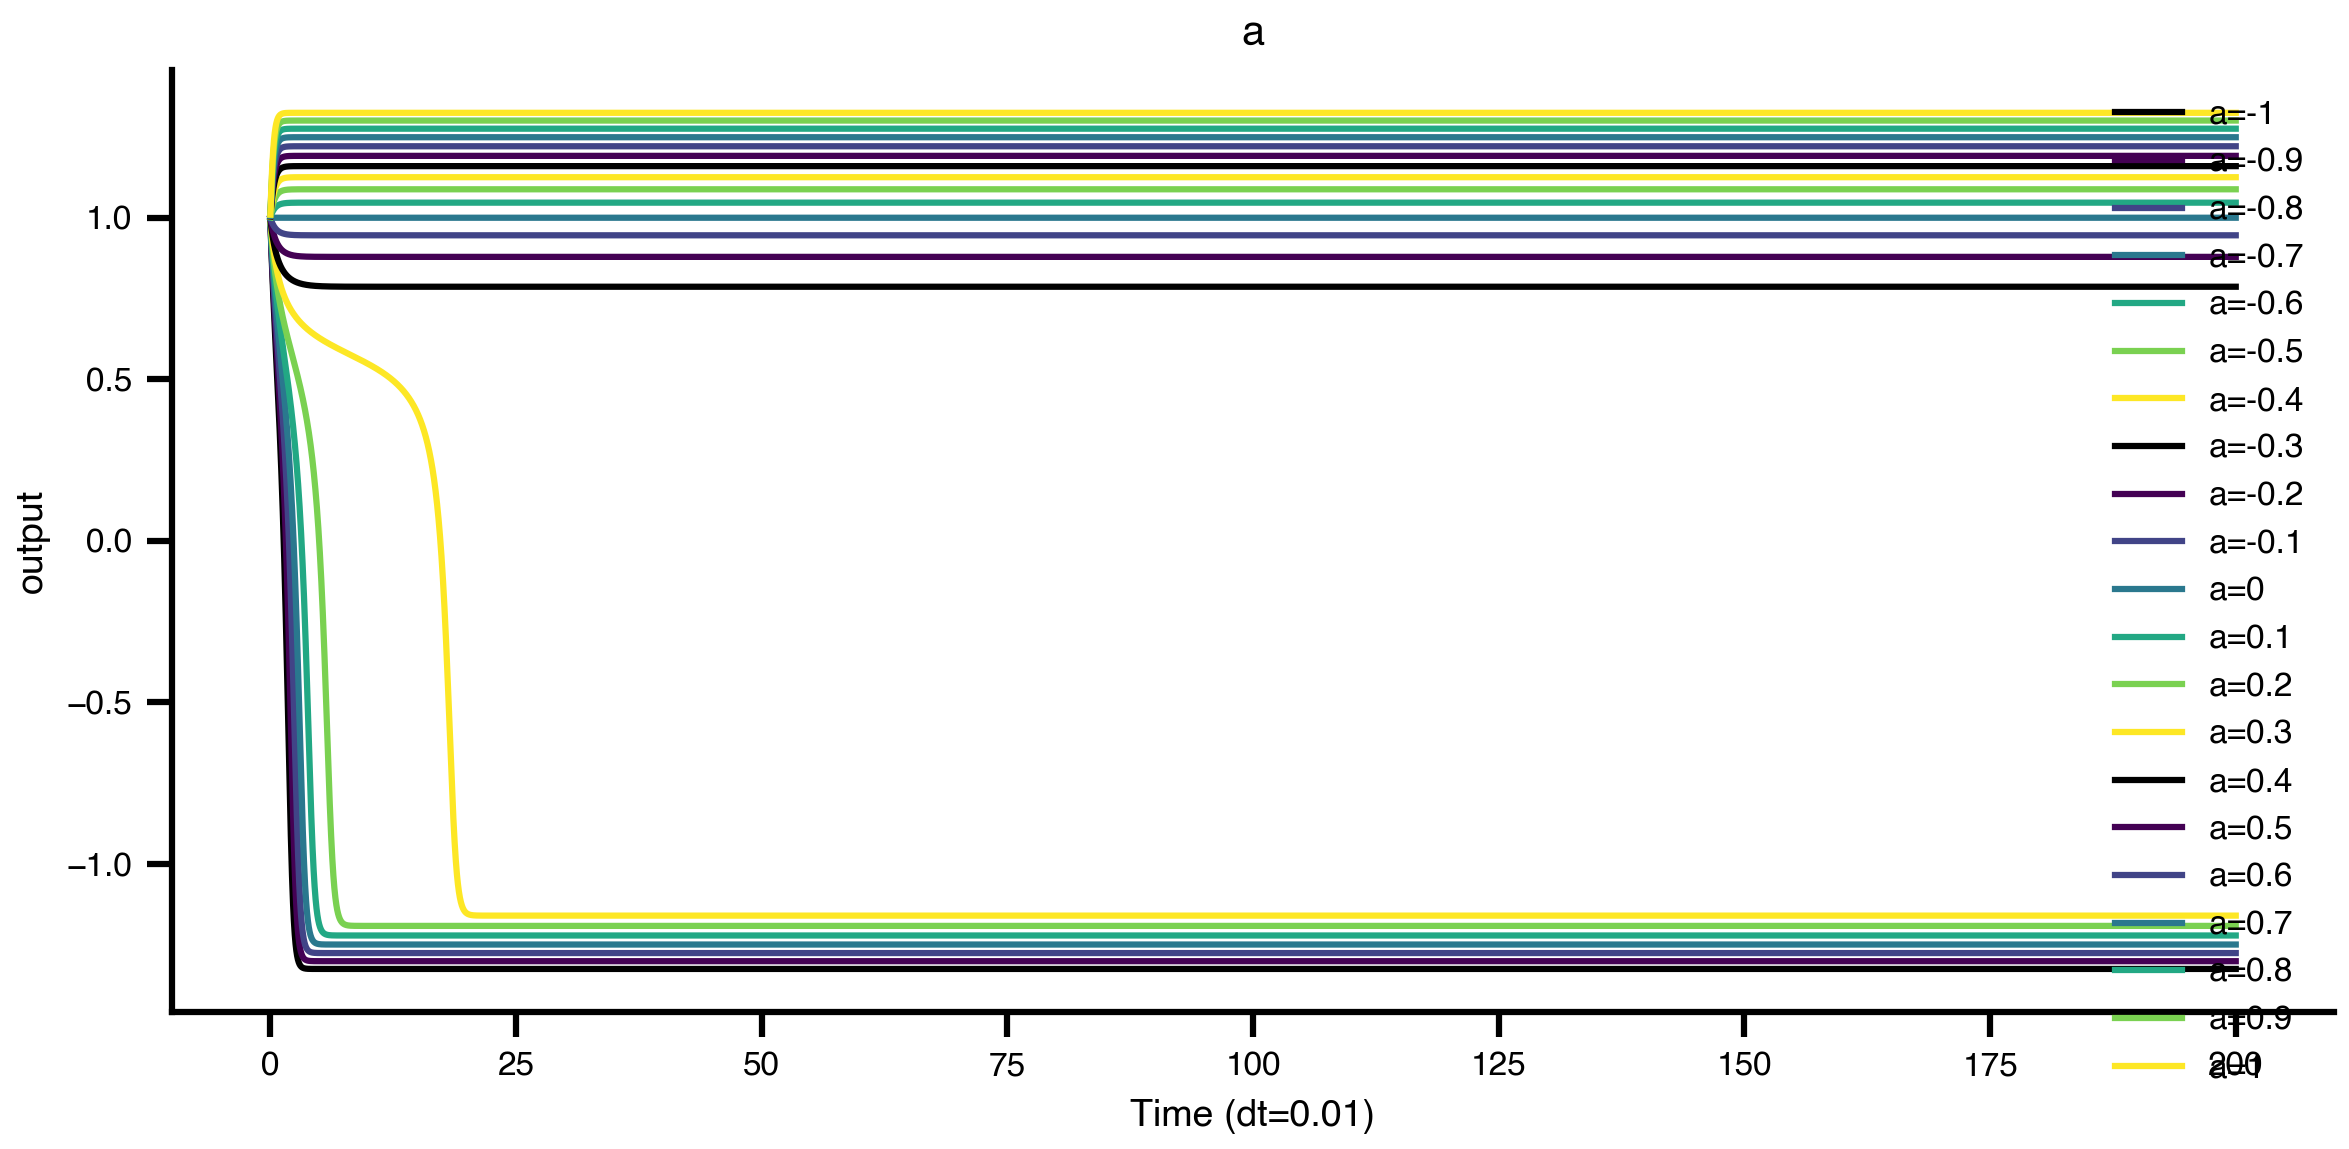

In [8]:
dyn_hi = Dynamics.from_string(HYSTERESIS)
dyn_hi.state_variables["x"].initial_value = 1.0
exp_hy_hi = SimulationExperiment(dynamics=dyn_hi)
exp_hy_hi.integration.duration = 200
exp_hy_hi.integration.step_size = 0.01
exp_hy_hi.explorations["a"] = Exploration(
    name="a",
    space=ExplorationAxis(parameter="a", explored_values=list(np.linspace(-1.0, 1.0, 21))),
)
exp_hy_hi.run("tvboptim").explorations["a"].plot(overlay=True)

## 4. Hopf normal form — birth of an oscillation

In 2D, a **Hopf bifurcation** occurs when a pair of complex-conjugate
eigenvalues crosses the imaginary axis. A stable focus turns into an
unstable focus surrounded by a stable **limit cycle** of radius
$\sqrt a$.

$$
\dot x_1 = (a - x_1^2 - x_2^2)\,x_1 - w\,x_2, \qquad
\dot x_2 = (a - x_1^2 - x_2^2)\,x_2 + w\,x_1.
$$

In [9]:
HOPF = r"""
name: HopfNF
parameters:
  a:
    name: a
    value: 0.5
  w:
    name: w
    value: 1.0
state_variables:
  x1:
    name: x1
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x1, t)
      rhs: (a - x1**2 - x2**2)*x1 - w*x2
    initial_value: 0.0
  x2:
    name: x2
    domain:
      lo: -2.0
      hi: 2.0
    equation:
      lhs: Derivative(x2, t)
      rhs: (a - x1**2 - x2**2)*x2 + w*x1
    initial_value: 0.0
"""

CONT_HOPF = """
name: hopf_in_a
dynamics: HopfNF
free_parameters:
  - name: a
    domain:
      lo: -2.0
      hi: 2.0
max_steps: 400
ds: 0.01
bothside: true
branches:
  - name: po_from_hopf
    source_point: "hopf:all"
    bothside: true
"""

dyn  = Dynamics.from_string(HOPF)
cont = Continuation.from_string(CONT_HOPF)
exp_hopf = SimulationExperiment(dynamics=dyn, continuations=[cont])
hopf = exp_hopf.run("bifurcationkit.jl").continuations["hopf_in_a"]

CT: 0.429842 seconds (883.67 k allocations: 42.933 MiB, 99.92% compilation time)
CT: 0.000190 seconds (2.14 k allocations: 191.859 KiB)
CT: 3.274408 seconds (3.80 M allocations: 546.513 MiB, 2.93% gc time, 92.93% compilation time)
CT: 0.228459 seconds (226.88 k allocations: 390.487 MiB, 8.46% gc time)

The 2D bifurcation diagram (`MIN`/`MAX` envelope of the limit cycle):

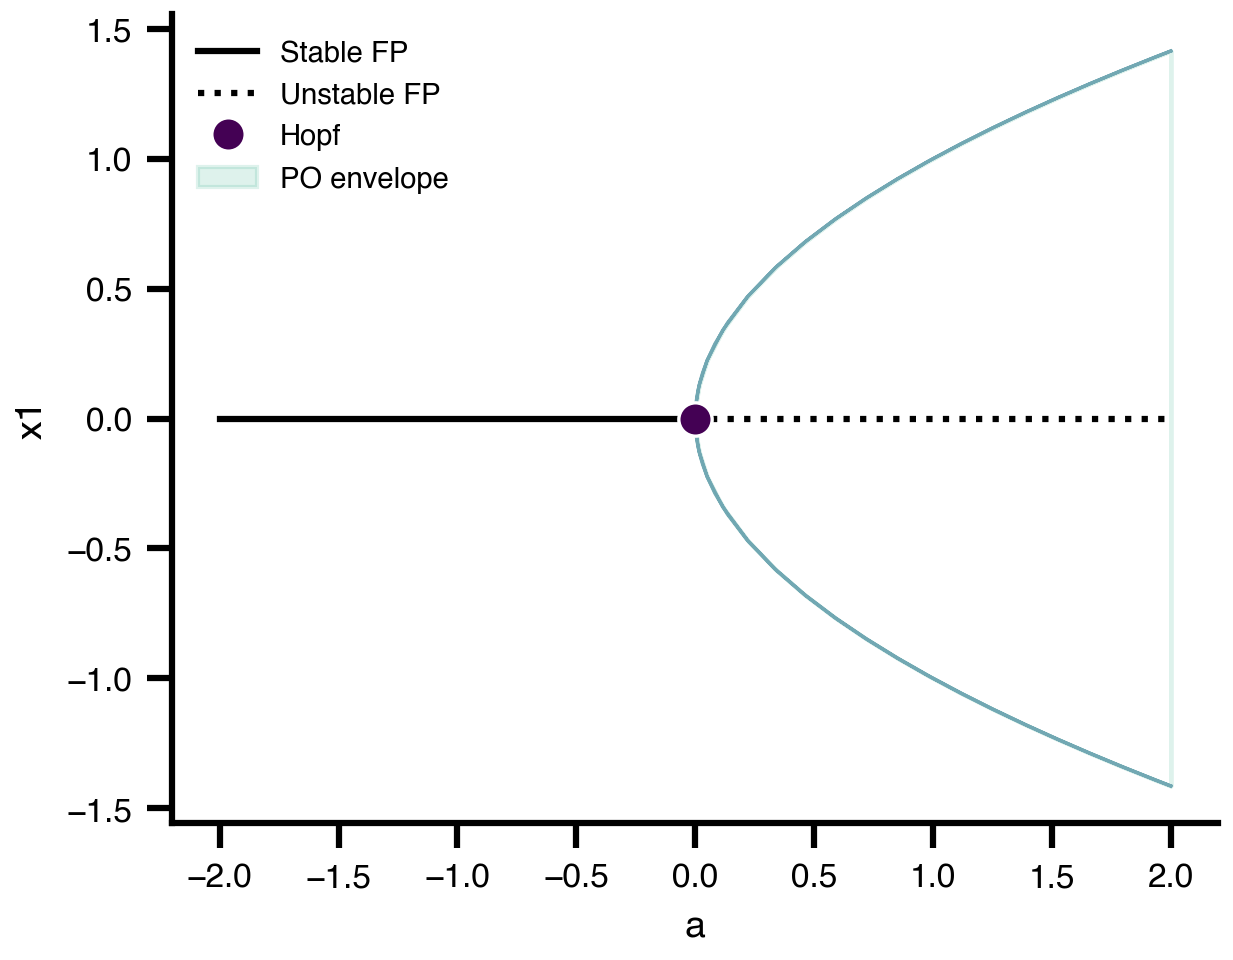

In [10]:
hopf.plot(VOI="x1"); plt.show()

The 3D view shows the equilibrium spine, the Hopf point, and the
limit-cycle **tube** whose radius grows like $\sqrt a$:

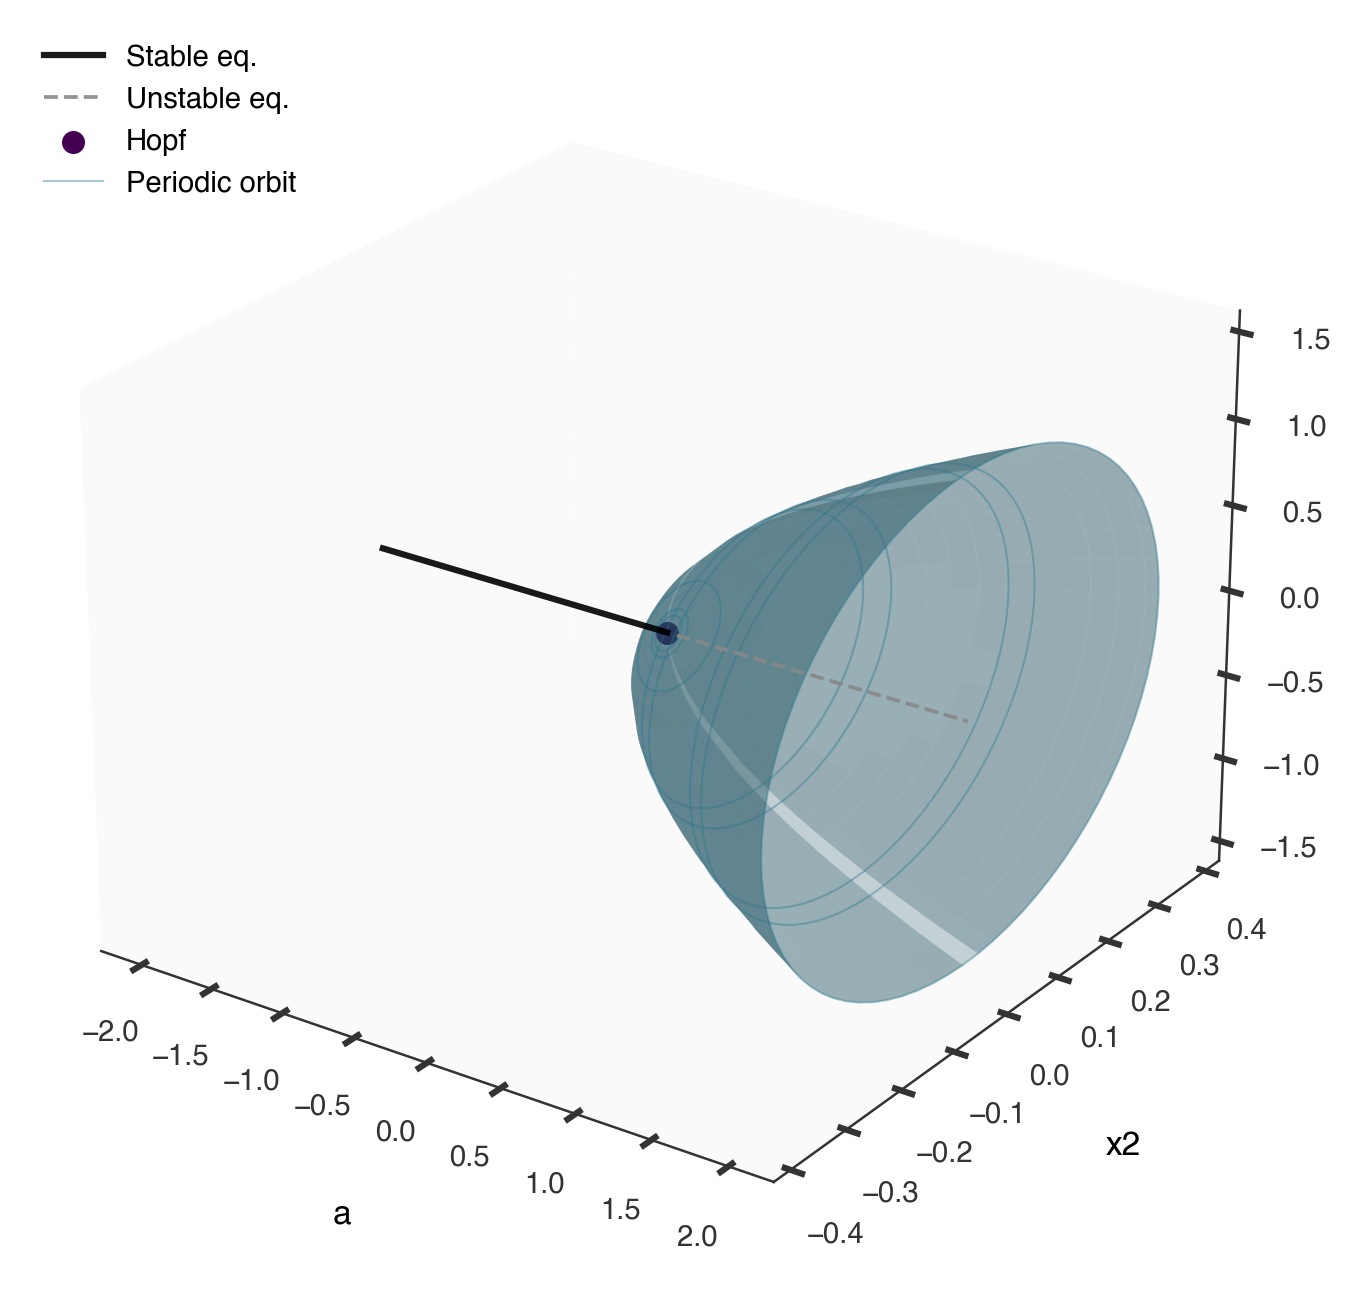

In [11]:
hopf.plot_3d(VOI="x1"); plt.show()

## 5. Numerical continuation in one paragraph

The backend (`bifurcationkit.jl`) tracks equilibria $f(x, a) = 0$ along
**arclength** $s$ instead of along $a$ directly. A
**predictor-corrector** scheme (tangent extrapolation + Newton on the
augmented system) walks past folds where $J$ becomes singular.
Bifurcations are flagged by sign changes in **test functions** ($\det J$
for folds, $\mathrm{Re}\,\lambda$ for Hopf, etc.). At a branch point the
corrector restarts in the eigenvector direction. This is **branch
switching**, and in TVBO it is requested declaratively:

``` yaml
branches:
  - name: po_from_hopf
    source_point: "hopf:all"
```

> Task: run the following example with and without the branches
> attributes

## 6. Brain-relevant: Generic2dOscillator

The same `Continuation` API drives a TVB neural-mass model. We sweep the
external input $I$ and let TVBO continue periodic orbits from every
detected Hopf point.

CT: 0.529753 seconds (907.09 k allocations: 44.922 MiB, 11.62% gc time, 99.54% compilation time)
CT: 0.005528 seconds (16.19 k allocations: 1.187 MiB, 82.37% compilation time)

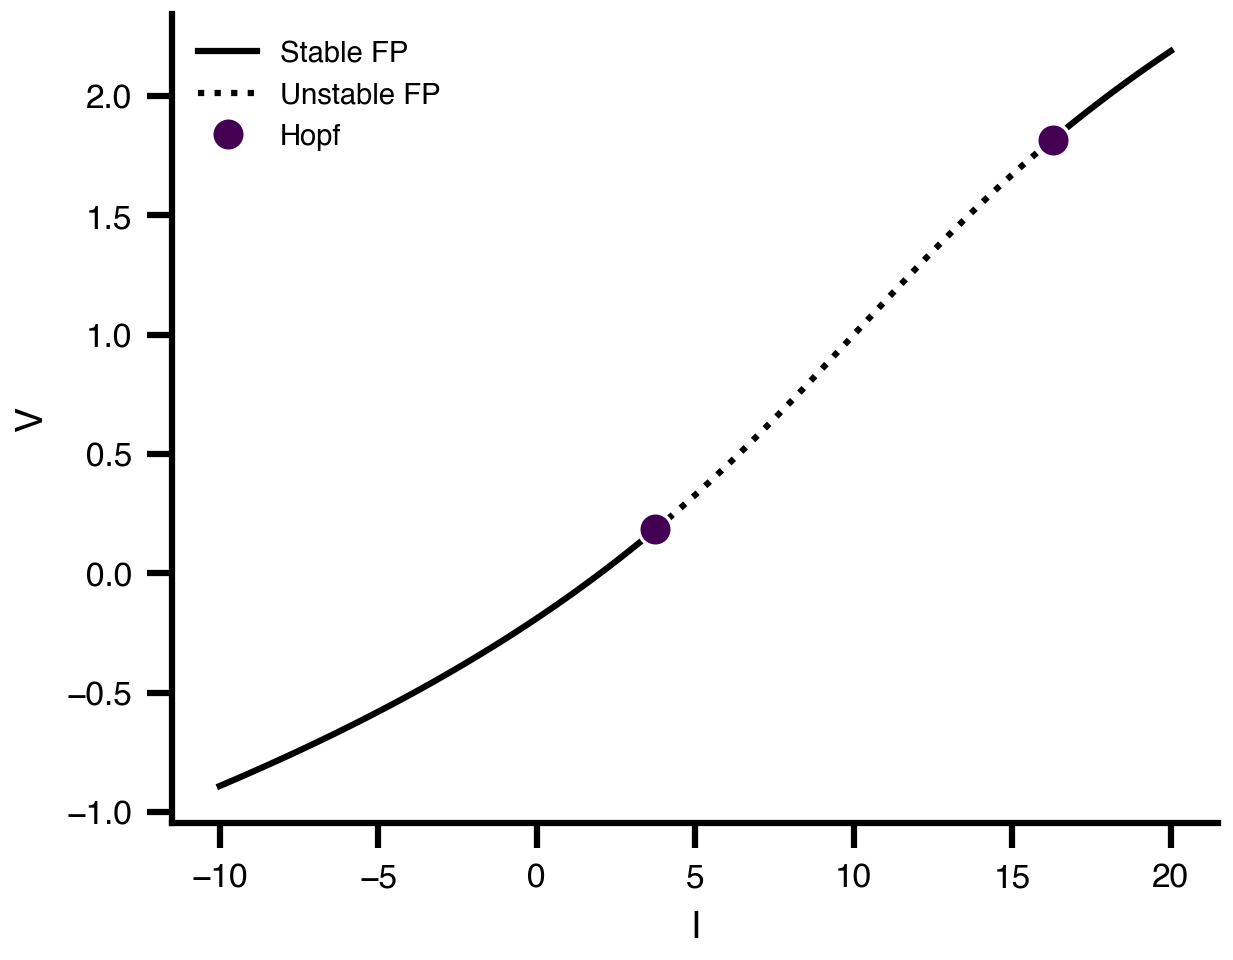

In [12]:
model = Dynamics.from_ontology("Generic2dOscillator")

cont = Continuation.from_string("""
name: g2d_in_I
dynamics: Generic2dOscillator
free_parameters:
  - name: I
    domain:
      lo: -10.0
      hi: 20.0
max_steps: 500
ds: 0.05
bothside: true
# branches:
#   - name: po_from_hopf
#     source_point: "hopf:all"
#     bothside: true
""")

exp_g2d = SimulationExperiment(dynamics=model, continuations=[cont])
g2d = exp_g2d.run("bifurcationkit.jl").continuations["g2d_in_I"]
g2d.plot(VOI="V"); plt.show()

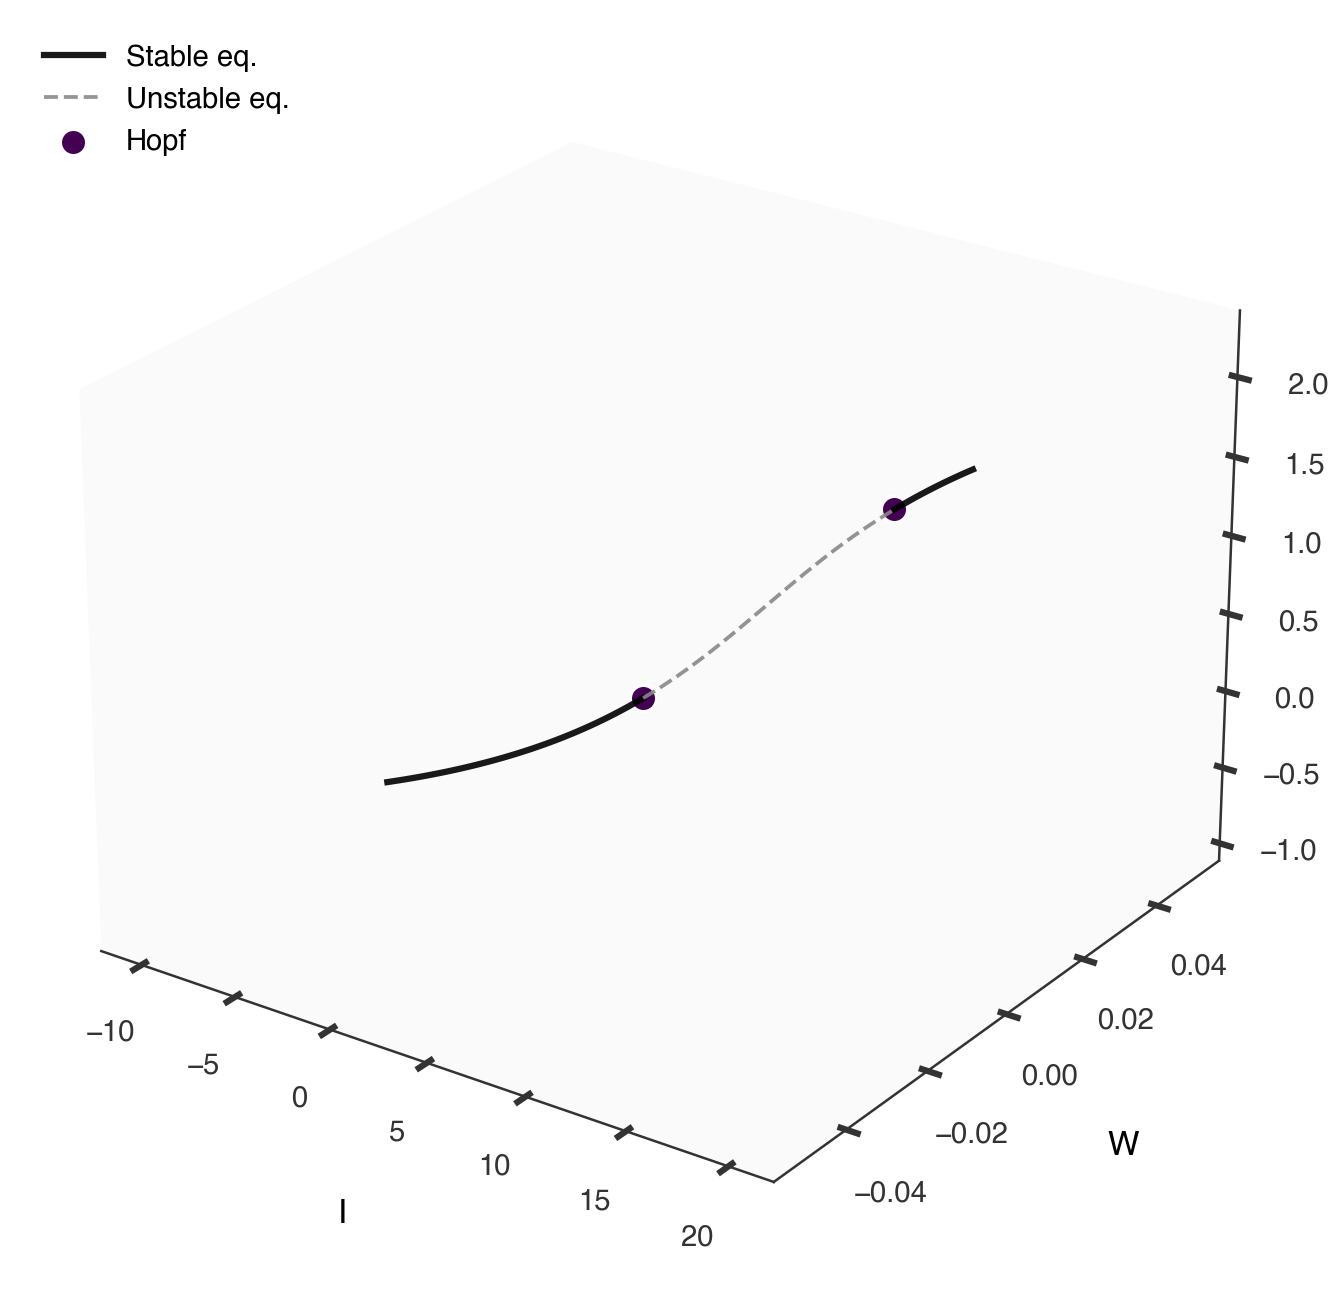

In [13]:
g2d.plot_3d(VOI="V"); plt.show()

**Reading the diagram:** stable branches → resting / persistent
activity; limit cycles → oscillatory regime; folds → abrupt regime
shifts (e.g. seizure onset). The same machinery applied to a whole-brain
network predicts where the *collective* dynamics changes regime as
global coupling or input is varied.

## Exercises

1.  Add a small constant input to the Hopf system:
    `rhs: (a - r**2)*x1 - w*x2 + I0`. Sweep `I0` instead of `a`. What
    kind of bifurcation do you see?
2.  In `Generic2dOscillator`, replace `I` by `b` as the free parameter.
    Where are the Hopf points now?